### Notebook for inspecting predictions made on noise waveforms and generating metrics

#### Finalised scripts are located at: [combine_predictions.py](../combine_predictions.py) and [create_prediction_metrics.py](../create_prediction_metrics.py).

#### Read individual .csv files with predictions and store as one single .csv

In [2]:
import os
from pathlib import Path
import glob
import re
import sys
import time
from datetime import datetime
import pandas as pd
import numpy as np
from obspy import read
import numpy as np
import matplotlib.pyplot as plt

# Define the type of waveforms used e.g. "earthquakes", "explosions"
waveform_type = "noise"
# Define the model e.g. "eqcct", "eqt"
model_type = "eqt"

# Path for .mseed data
data_dir = f"../data/waveforms_noise_only/"

# Base path: where to gather the outputs from
# csv output path: where to store the combined csv
base_path = "../results/csv/" 
subdir = f"{model_type}_{waveform_type}_th0_1"

csv_output_path = os.path.join(base_path, "combined")
csv_output_name = subdir + "_full.csv"

# Match filenames to only get the csv outputs
files = list(Path(base_path + subdir).rglob("*.csv"))

# Sort files by timechunk folder name (0 = station, 1 = timechunk)
files = sorted(files, key=lambda x:x.parents[1].name)

# Load files
dfs = []

# Start and end times of the time windows as in the folder names
pattern = re.compile(r"(?P<start>\d{8}T\d{6}Z)_(?P<end>\d{8}T\d{6}Z)")
for file in files:
    df_tmp = pd.read_csv(file)

    # Extract time window from folder name
    # e.g. .../20250101T092157Z_20250101T092257Z/HEF_outputs/X_prediction_results.csv
    folder = file.parents[1].name

    m = pattern.match(folder)
    if not m:
        raise ValueError(f"Could not parse folder name: {folder}")

    start_dt = pd.to_datetime(m.group("start"), format="%Y%m%dT%H%M%SZ")
    end_dt = pd.to_datetime(m.group("end"), format="%Y%m%dT%H%M%SZ")

    # Attach to dataframe
    df_tmp["start_dt"] = start_dt
    df_tmp["end_dt"] = end_dt

    # Store the filename of the waveform
    df_tmp["source_file"] = str(file.relative_to(base_path))
    dfs.append(df_tmp)

# Combine into single df
df = pd.concat(dfs, ignore_index=True)

# Keep only rows with predictions
pred_cols = ["p_probability", "s_probability"]

# Extract raw datetime string from time window directories
mseed_pattern = r"(?P<station>[^/]+)/(?P<network>[^.]+)\.(?P=station)\.\.(?P<channel>[A-Z]{3})__(?P<start_dt>\d{8}T\d{6}Z)__(?P<end_dt>\d{8}T\d{6}Z)\.mseed"
matches = df["file_name"].str.extract(mseed_pattern)

# If filename information is present in predictions, use it to infer network and station codes
# This is done because eqcct assigns 0 as the network code for some reason
if matches.notna().all().all():
    df["network"] = matches["network"].str.strip().str.upper()
    df["station"] = matches["station"].str.strip().str.upper()

# With EQT, the .mseed filename is not available, but network and station should be correct in the predictions .csv
else:
    df["network"] = df["network"].str.strip().str.upper()
    df["station"] = df["station"].str.strip().str.upper()

# Convert arrivals to datetime
df["p_arrival_time"] = pd.to_datetime(df["p_arrival_time"], errors="coerce")
df["s_arrival_time"] = pd.to_datetime(df["s_arrival_time"], errors="coerce")

# Filter out rows with NaN for both p_probability and s_probability (no predicted picks)
df = df[df["p_probability"].notna() | df["s_probability"].notna()]

# Sort df by the window start time
df = df.sort_values(by="start_dt", ascending=True)
# Save dataframe to csv
os.makedirs(csv_output_path, exist_ok=True)
df.to_csv(os.path.join(csv_output_path, csv_output_name), index=False)

# Print some basic information about the number of predicted picks
num_rows = len(df)
num_files = len(files)
num_p_picks = sum(df["p_probability"].notna())
num_s_picks = sum(df["s_probability"].notna())
num_negatives = sum(df["p_probability"].isna() & df["s_probability"].isna())

print(f"Read {num_rows} rows from {num_files} files.")
print(f"Number of predicted p-arrivals: {num_p_picks}\nNumber of predicted s-arrivals: {num_s_picks}\nTotal number of arrivals: {num_p_picks+num_s_picks}")
print(f"Number of empty predictions: {num_negatives}")

Read 102 rows from 2004 files.
Number of predicted p-arrivals: 66
Number of predicted s-arrivals: 73
Total number of arrivals: 139
Number of empty predictions: 0


### Plot waveforms and predicted p/s picks

In [5]:
from obspy import Stream, UTCDateTime
from collections import defaultdict

def build_waveform_index(data_dir):

    index = defaultdict(list)

    # Patterns to match
    # .mseed filename
    file_pattern = re.compile(r"(?P<network>[^.]+)\.(?P<station>[^.]+)\.\.(?P<channel>[A-Z0-9]+)__(?P<start>\d{8}T\d{6}Z)__(?P<end>\d{8}T\d{6}Z)\.mseed")
    # directory containing time window e.g. "20250102T044222Z_20250102T044322Z"
    dir_pattern = re.compile(r"(?P<start>\d{8}T\d{6}Z)_(?P<end>\d{8}T\d{6}Z)")

    for entry in os.scandir(data_dir):
        if not entry.is_dir():
            continue

        dir_match = dir_pattern.fullmatch(entry.name)
        if not dir_match:
            continue

        dir_start = dir_match.group("start")
        dir_end = dir_match.group("end")

        # Iterate over .mseed files in the subdirectories
        for root, _, files in os.walk(entry.path):
            for f in files:
                if not f.endswith(".mseed"):
                    continue

                f = f.strip()
                m = file_pattern.fullmatch(f)
                if not m:
                    print("No match:", f)
                    continue

                network = m.group("network")
                station = m.group("station")

                key = (network, station, dir_start, dir_end)
                path = os.path.join(root, f)

                index[key].append(path)

    return index


# Load a time window at a given network and station
def load_station_window(index, network, station, start_dt, end_dt):

    # Convert datetime of time windows to match the format in the directory names
    start_str = UTCDateTime(start_dt).strftime("%Y%m%dT%H%M%SZ")
    end_str = UTCDateTime(end_dt).strftime("%Y%m%dT%H%M%SZ")

    key = (network, station, start_str, end_str)

    st = Stream()

    if key not in index:
        print("Missing waveform:", key)
        return st

    for path in index[key]:
        st += read(path)

    if len(st) == 0:
        return st

    start = UTCDateTime(start_dt)
    end = UTCDateTime(end_dt)
    st.merge(method=1, fill_value="interpolate")
    st.trim(start, end)

    return st


# Plot a row from the prediction results dataframe
def plot_pred_row(row, waveform_idx, p_tr=0.01):

    # Skip low-probability rows
    if not (
        (pd.notna(row.p_probability) and row.p_probability > p_tr) or
        (pd.notna(row.s_probability) and row.s_probability > p_tr)
    ):
        return

    st = load_station_window(
        waveform_idx,
        row.network,
        row.station,
        row.start_dt,
        row.end_dt
    )

    if len(st) == 0:
        print("No waveform:", row.station, row.start_dt)
        return

    # Downsample to 100Hz if needed
    for tr in st:
        if tr.stats.sampling_rate > 100:
            tr.resample(100)

    # Generate the plot
    fig, axes = plt.subplots(3,1,figsize=(10,6),sharex=True)
    fig.suptitle(f"{row.network}.{row.station}  {row.start_dt} to {row.end_dt}", fontsize=10)

    # Get the list of channels for the current stream
    channels = [tr.stats.channel for tr in st]

    for j, ch in enumerate(channels):
        # Trace for currently selected channel
        tr_sel = st.select(channel=ch)
        # Don't plot if there are no traces
        if len(tr_sel) == 0:
            continue

        # Waveform processing
        tr = tr_sel[0].copy()
        tr.detrend("linear")
        tr.detrend("demean")
        tr.filter("bandpass", freqmin=1, freqmax=45, corners=2, zerophase=True)
        tr.taper(max_percentage=0.01, type='cosine', max_length=2)
        tr.normalize()

        # Time axis
        t = tr.times()
        
        axes[j].plot(t, tr.data, color="grey", linewidth=1)

        # Predicted p-arrival
        if pd.notna(row.p_arrival_time):
            time_pred = UTCDateTime(row.p_arrival_time) - tr.stats.starttime
            axes[j].axvline(time_pred, color="b", linewidth=1.5, linestyle="dashed", label=f"P-pred (p={row.p_probability:.3f})")

        # Predicted s-arrival
        if pd.notna(row.s_arrival_time):
            time_pred = UTCDateTime(row.s_arrival_time) - tr.stats.starttime
            axes[j].axvline(time_pred, color="r", linewidth=1.5, linestyle="dashed", label=f"S-pred (p={row.s_probability:.3f})")

        axes[j].set_ylabel(ch)
        axes[j].legend(loc="lower right")

    axes[-1].set_xlabel("Time (s)")
    plt.tight_layout()
    plt.show()

    return True

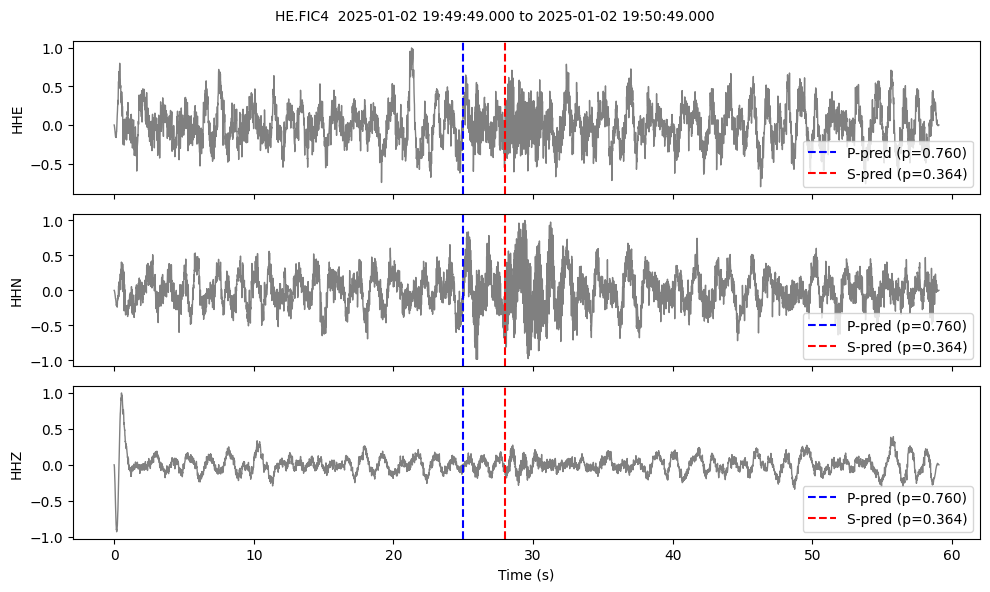

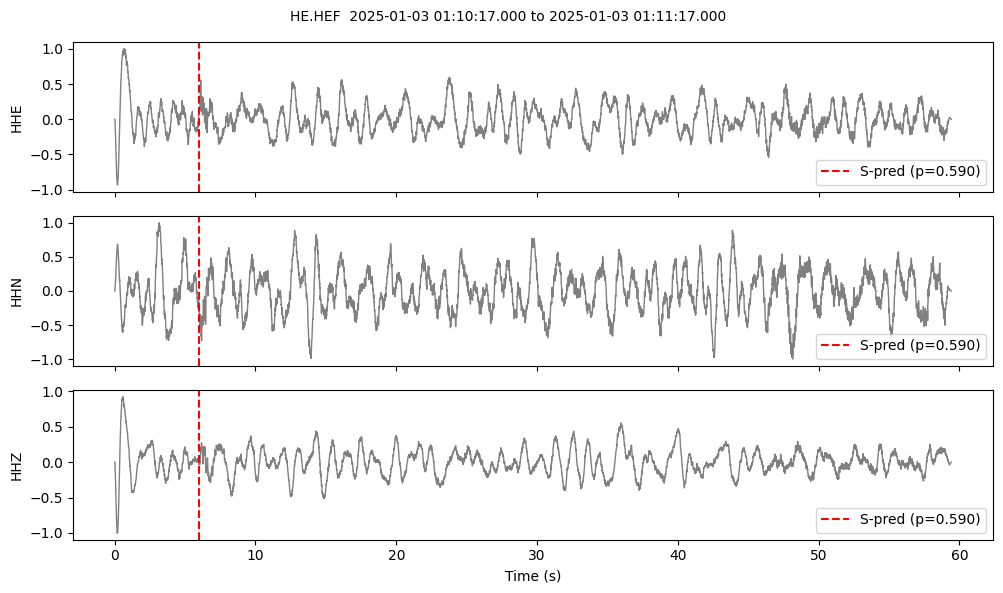

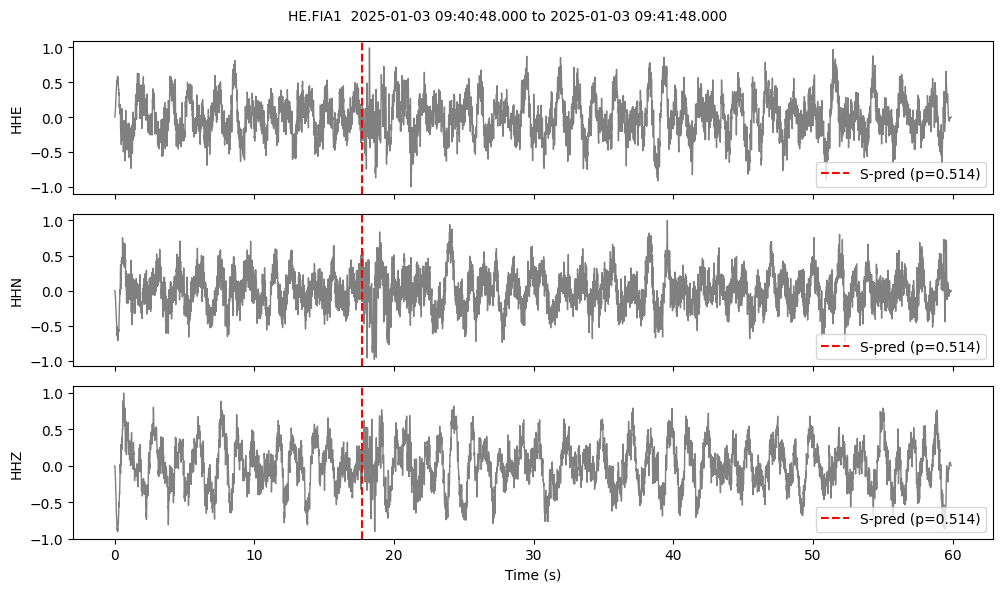

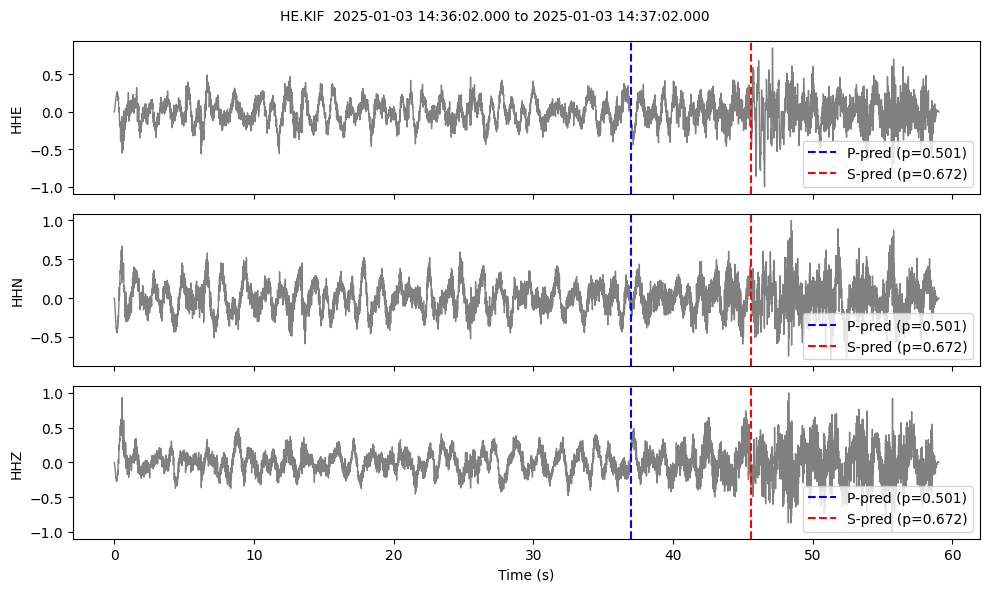

In [14]:
# Build indices for the waveforms
waveform_idx = build_waveform_index(data_dir)

# Load data from .csv file with combined predictions
df = pd.read_csv(os.path.join(csv_output_path, csv_output_name))

# Test plots
num_plots = 10
counter = 0

for _, row in df.head(20).iterrows():
    plotted = plot_pred_row(row, waveform_idx, p_tr=0.5)
    if plotted:
        counter += 1
        if counter >= num_plots:
            break